# Домашнее задание 4. Механизм внимания и архитектура Transformer


## Структура домашней работы

Домашнее задание состоит из 9 задач, разделенных на три уровня сложности:

| Уровень | Задачи | Баллы |
|---------|--------|-------|
| **Простые** | 1—4 | 3 (0.75 за задачу) |
| **Средние** | 5—7 | 3 (1 за задачу) |
| **Сложные** | 8—9 | 4 (2 за задачу) |

**Итого:** 10 баллов

## Настройка окружения

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Dataset
import seaborn as sns
import math
import copy
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

# device = "cpu"
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

Device: cuda


---

## Теоретический минимум

### Ограничения рекуррентных сетей (RNN)

RNN обрабатывают последовательность **последовательно**: $h_t = f(h_{t-1}, x_t)$.

Проблемы:
- Нельзя параллелизовать вычисления по позициям.
- Затухание/взрыв градиентов при длинных последовательностях (BPTT).
- Плохое моделирование дальних зависимостей.

### Идея внимания (Attention)

Вместо сжатия всей последовательности в один вектор — разрешить модели
«смотреть» на все позиции входа одновременно, взвешивая их по релевантности.

### Queries, Keys, Values

Входная последовательность $X \in \mathbb{R}^{N \times D}$ проецируется в три пространства:

$$Q = X W_Q, \quad K = X W_K, \quad V = X W_V$$

где $W_Q, W_K \in \mathbb{R}^{D \times d_k}$, $W_V \in \mathbb{R}^{D \times d_v}$.

### Scaled Dot-Product Attention

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{Q K^T}{\sqrt{d_k}}\right) V$$

- $QK^T \in \mathbb{R}^{N \times N}$ — матрица «похожестей» между позициями.
- Деление на $\sqrt{d_k}$ предотвращает насыщение softmax при больших $d_k$.

### Multi-Head Attention

$$\text{MultiHead}(Q,K,V) = \text{Concat}(\text{head}_1, \ldots, \text{head}_h)\,W_O$$

$$\text{head}_i = \text{Attention}(Q W_Q^i, K W_K^i, V W_V^i)$$

Разные головы захватывают разные типы зависимостей.

### Слой Transformer

```
x -> MultiHeadAttention -> Add & LayerNorm -> FFN -> Add & LayerNorm -> output
```

FFN: два линейных слоя с ReLU: $\text{FFN}(x) = \max(0, x W_1 + b_1) W_2 + b_2$.

### Позиционное кодирование

Без позиционной информации self-attention инвариантен к перестановкам.
Синусоидальное кодирование:

$$PE(pos, 2i) = \sin\!\left(\frac{pos}{10000^{2i/d}}\right), \quad
PE(pos, 2i+1) = \cos\!\left(\frac{pos}{10000^{2i/d}}\right)$$

### Causal Mask

Для авторегрессивных моделей (decoder) нужно запретить токену «видеть» будущие
позиции. Это достигается маской — нижнетреугольной матрицей.

### Токенизация

- **Word-level**: слова как токены. Большой словарь, проблема OOV.
- **Char-level**: символы как токены. Маленький словарь, длинные последовательности.
- **Subword (BPE)**: компромисс. Частые слова целиком, редкие — по частям.

### Вычислительная сложность

Self-attention: $O(N^2 \cdot d)$ по времени и $O(N^2)$ по памяти (матрица $N \times N$).
FFN: $O(N \cdot d \cdot d_{ff})$.


---

# ПРОСТЫЕ ЗАДАЧИ (1—4)

Понимание механизма attention: формулы, размерности, масштабирование.

## Задача 1. Ручной расчет attention на 3 токенах

### Постановка задачи

На маленьком примере (3 токена, $d_k = 4$) пошагово вычислите scaled dot-product attention.

### Задача
1. Задайте Q, K, V размерности (3, 4) вручную.
2. Вычислите $QK^T$, масштабируйте на $\sqrt{d_k}$, примените softmax, умножьте на $V$.
3. Покажите каждый промежуточный результат.
4. Сравните softmax с масштабированием и без — покажите, что без масштабирования распределение более «острое».


### Заметки студента

$$
SoftmaxRows(\text{S})_{ij}=\frac{e^{S_{ij}}}{\sum_{k=1}^{seq_k}e^{S_{ik}}}
$$

In [2]:
# Задача 1. Ручной расчет attention

def softmax_rows(S: np.ndarray) -> np.ndarray:
    """Функция возвращает вычисление softmax по строкам,
        где S - входная матрица оценок (scores)
    Параметр axis=-1 сделал функцию более универсальной для матриц
        размерностей выше 2D
    Переменая A_max_per_pow нужна для избежания затуханий/взрывов
    """
    S_max_per_pow = np.max(S, axis=-1, keepdims=True)
    exp_S = np.exp(S - S_max_per_pow)
    return exp_S / np.sum(exp_S, axis=-1, keepdims=True)


# Зададим Q, K, V вручную (3 токена, d_k = 4)
Q = torch.tensor([[1.0, 0.0, 1.0, 0.0],
                  [0.0, 1.0, 0.0, 1.0],
                  [1.0, 1.0, 0.0, 0.0]], dtype=torch.float32)

K = torch.tensor([[1.0, 0.0, 0.0, 1.0],
                  [0.0, 1.0, 1.0, 0.0],
                  [1.0, 1.0, 1.0, 1.0]], dtype=torch.float32)

V = torch.tensor([[1.0, 2.0],
                  [3.0, 4.0],
                  [5.0, 6.0]], dtype=torch.float32)

dim = -1
d_k = Q.shape[dim]

# ======================== С масштабированием: =========================
# Шаг 1. QK^T = E - estimations или S - scores
E = Q @ K.transpose(-2, -1)  # .T работает только на 2d
print("Шаг 1. Q·K^T (сырые оценки):")
print(E)
print()

# Шаг 2. Масштабирование
scaled_E = E / d_k ** (1/2)
print("Шаг 2. Q·K^T / sqrt(d_k=4) = Q·K^T / 2.00:")
print(scaled_E)
print()

# Шаг 3. Softmax
scaled_W = torch.from_numpy(softmax_rows(scaled_E.numpy()))
print("Шаг 3. softmax(веса внимания):")
print(scaled_W)
print("  " + "Суммы по строкам:", scaled_W.sum(dim=1))
print()

# Шаг 4. Умножение на V
scaled_A = scaled_W @ V
print("Шаг 4. Attention(Q,K,V) = weights @ V:")
print(scaled_A)
print()

# ======================== Без масштабирования: ========================
print("-" * 22 + " Сравнение: softmax БЕЗ масштабирования " + "-" * 21)
print("С масштабированием: ", scaled_W[-1].numpy().tolist())
W = torch.from_numpy(softmax_rows(E.numpy()))
print("Без масштабирования:", W[-1].numpy().tolist())
print()

print()
print("Без масштабирования дисперсия по строкам выше в сравнении с " + 
      "масштабированными весами, \nчто говорит о более `остром` распределении " +
      "весовых коэффициентов.")

Шаг 1. Q·K^T (сырые оценки):
tensor([[1., 1., 2.],
        [1., 1., 2.],
        [1., 1., 2.]])

Шаг 2. Q·K^T / sqrt(d_k=4) = Q·K^T / 2.00:
tensor([[0.5000, 0.5000, 1.0000],
        [0.5000, 0.5000, 1.0000],
        [0.5000, 0.5000, 1.0000]])

Шаг 3. softmax(веса внимания):
tensor([[0.2741, 0.2741, 0.4519],
        [0.2741, 0.2741, 0.4519],
        [0.2741, 0.2741, 0.4519]])
  Суммы по строкам: tensor([1., 1., 1.])

Шаг 4. Attention(Q,K,V) = weights @ V:
tensor([[3.3556, 4.3556],
        [3.3556, 4.3556],
        [3.3556, 4.3556]])

---------------------- Сравнение: softmax БЕЗ масштабирования ---------------------
С масштабированием:  [0.2740686237812042, 0.2740686237812042, 0.45186275243759155]
Без масштабирования: [0.21194155514240265, 0.21194155514240265, 0.5761169195175171]


Без масштабирования дисперсия по строкам выше в сравнении с масштабированными весами, 
что говорит о более `остром` распределении весовых коэффициентов.


---

## Задача 2. Реализация scaled dot-product attention

### Постановка задачи

Реализуйте функцию `scaled_dot_product_attention(Q, K, V, mask=None)`
и протестируйте на случайных данных.

### Задача
1. Реализуйте формулу: $\text{softmax}(QK^T / \sqrt{d_k}) \cdot V$.
2. Если mask задана, замените замаскированные позиции на $-10^9$ перед softmax.
3. Верните (output, attention_weights).
4. Проверьте: корректность форм, суммы softmax = 1.


In [3]:
# Задача 2. Scaled dot-product attention

def scaled_dot_product_attention(Q, K, V, *, mask=None):
    """
    Scaled dot-product attention.

    Аргументы:
        Q: (batch, seq_q, d_k)
        K: (batch, seq_k, d_k)
        V: (batch, seq_k, d_v)
        mask: (batch, seq_q, seq_k) или (seq_q, seq_k), 0 = маскировать

    Возвращает:
        output: (batch, seq_q, d_v)
        weights: (batch, seq_q, seq_k)
    """
    d_k = K.shape[-1]
    E = Q @ K.transpose(-2, -1)  # .T работает только на 2d
    scaled_E = E / d_k ** (1/2)

    if mask is not None:
        if mask.dim() == 2:
            mask = mask.unsqueeze(0)
        scaled_E = scaled_E.masked_fill(mask==0, -1e9)
    
    W = torch.from_numpy(softmax_rows(scaled_E.numpy()))
    A = W @ V
    return A, W


# ============================ Тестирование ============================
Q = torch.randn(2, 5, 8)  # 2 пердложения из 5 слов(токенов), размерность эмбеддинга 8
K = torch.randn(2, 5, 8)
V = torch.randn(2, 5, 8)

output, weights = scaled_dot_product_attention(Q, K, V)

print(f"Q shape: {Q.shape}")
print(f"K shape: {K.shape}")
print(f"V shape: {V.shape}")
print(f"Output shape: {output.shape}")
print(f"Weights shape: {weights.shape}")
print()

# Проверка: суммы softmax = 1
row_sums = weights.sum(dim=-1)
print("Суммы строк weights (должны быть ~1.0):")
print(f"  min={row_sums.min():.6f}",  f"max={row_sums.max():.6f}")
print("  Все суммы равны 1. " + 
      ("[OK]" if row_sums.median() == 1. else "  Ошибка"))
print()


# ============================== С маской ==============================
mask = torch.tensor(
    [
        [1, 1, 1, 0, 0],
        [1, 1, 1, 0, 0],
        [1, 1, 1, 0, 0],
        [1, 1, 1, 0, 0],
        [1, 1, 1, 0, 0]
    ], dtype=torch.bool
)

output, masked_weights = scaled_dot_product_attention(Q, K, V, mask=mask)
print("  Веса для первого примера, первый токен:",
         masked_weights[0][0].numpy().tolist())
print("  Сумма весов для первого примера, первого токена: %.6f" %
         masked_weights[0][0].sum())
print("  Замаскированные позиции ~ 0:",
         masked_weights[0][0][masked_weights[0][0] == 0].numpy().tolist())

Q shape: torch.Size([2, 5, 8])
K shape: torch.Size([2, 5, 8])
V shape: torch.Size([2, 5, 8])
Output shape: torch.Size([2, 5, 8])
Weights shape: torch.Size([2, 5, 5])

Суммы строк weights (должны быть ~1.0):
  min=1.000000 max=1.000000
  Все суммы равны 1. [OK]

  Веса для первого примера, первый токен: [0.4934648871421814, 0.2797214388847351, 0.2268136441707611, 0.0, 0.0]
  Сумма весов для первого примера, первого токена: 1.000000
  Замаскированные позиции ~ 0: [0.0, 0.0]


---

## Задача 3. Маскирование: causal mask и padding mask

### Постановка задачи

Реализуйте два типа масок и покажите их влияние на веса внимания.

### Задача
1. `causal_mask(seq_len)`: нижнетреугольная матрица (запрет на «будущие» позиции).
2. `padding_mask(lengths, max_len)`: маска для последовательностей разной длины.
3. Визуализируйте обе маски как heatmap.
4. Покажите attention weights с causal mask и без.


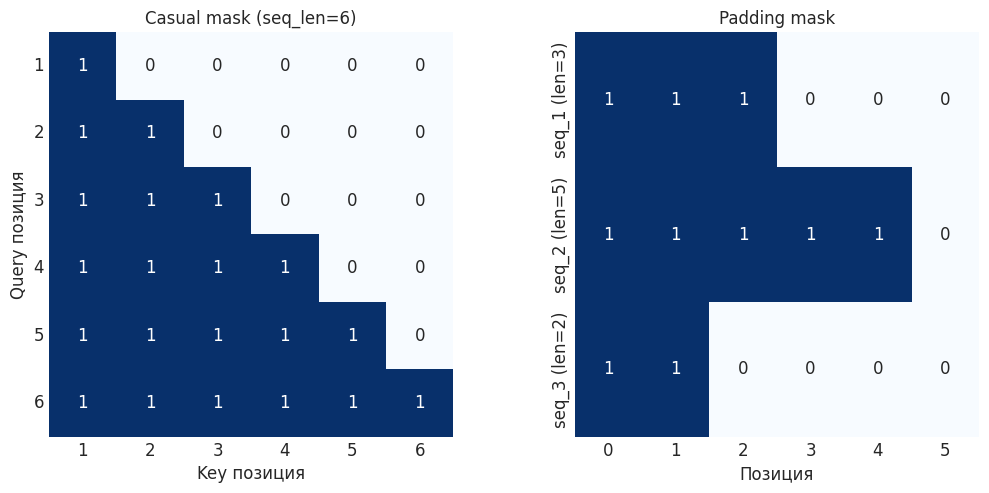

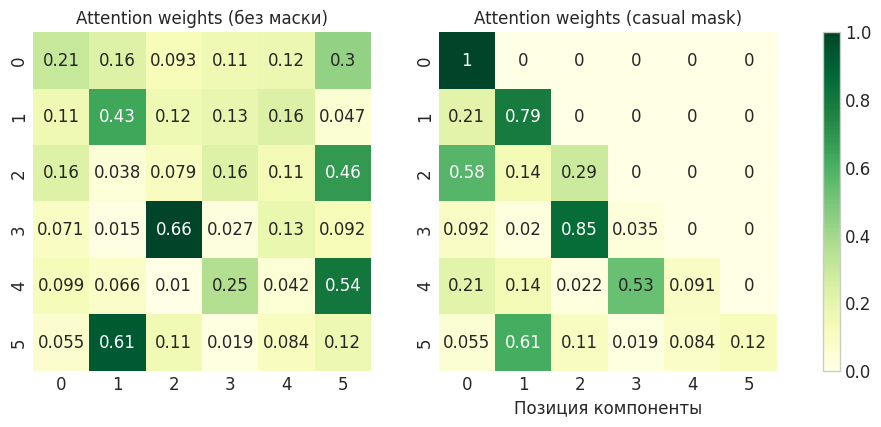

Вывод: `causal mask` обнуляет внимание к будущим позициям, 
что необходимо для авторегрессивной генерации.


In [4]:
# Задача 3. Causal mask и padding mask

def causal_mask(seq_len):
    """Нижнетреугольная маска (1 = разрешено, 0 = запрещено)."""
    """Сперва сделал самостоятельную реализацию на цикле,
    затем нашел метод, который делает всё то-же самое, но без цикла"""
    # mask = torch.zeros(seq_len, seq_len)
    # for i, seq in enumerate(mask, 1):
    #     seq[:i] = 1
    # return mask
    return torch.tril(torch.ones(seq_len, seq_len))

def padding_mask(lengths, max_len):
    """Маска для padding: lengths --- длины последовательностей в батче."""
    mask = torch.ones(len(lengths), max_len)
    for i, l in enumerate(lengths):
        mask[i, l:] = 0

    return mask


# ========================= Визуализация масок =========================
Q = torch.randn(1, 6, 8)  # 2 пердложения из 5 слов(токенов), размерность эмбеддинга 8
K = torch.randn(1, 6, 8)
V = torch.randn(1, 6, 8)
seq_len = Q.shape[1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8))
sns.heatmap(causal_mask(seq_len=seq_len),
            square=True,
            ax=ax1,
            cmap="Blues",
            annot=True,
            cbar=False)
ax1.set_title(f"Casual mask (seq_len={seq_len})", size=12)
ax1.set_xticklabels(range(1, seq_len+1))
ax1.set_yticklabels(range(1, seq_len+1), rotation=0)
ax1.set_ylabel("Query позиция", size=12)
ax1.set_xlabel("Key позиция", size=12)
ax1.set_box_aspect(1)

sns.heatmap(padding_mask((3, 5, 2), seq_len),
            ax=ax2,
            cmap="Blues",
            annot=True,
            cbar=False)
ax2.set_title(f"Padding mask", size=12)
ax2.set_yticklabels(["seq_1 (len=3)", "seq_2 (len=5)", "seq_3 (len=2)"],
                    rotation=90)
ax2.set_xlabel("Позиция", size=12)
ax2.set_box_aspect(1)

plt.subplots_adjust(wspace=0.3)
plt.show()

# ==================== Attention с causal mask и без ===================
_, w_no_mask = scaled_dot_product_attention(Q, K, V,
                                            mask=None)
_, w_causal  = scaled_dot_product_attention(Q, K, V,
                                            mask=causal_mask(seq_len=seq_len))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8))
h1 = sns.heatmap(w_no_mask[0],
            ax=ax1,
            cmap="YlGn",
            annot=True,
            cbar=False)
ax1.set_title("Attention weights (без маски)", size=12)
ax1.set_box_aspect(1)

h2 = sns.heatmap(w_causal[0],
            ax=ax2,
            cmap="YlGn",
            annot=True,
            cbar=False)
ax2.set_title("Attention weights (casual mask)", size=12)
ax2.set_xlabel("Позиция компоненты", size=12)
ax2.set_box_aspect(1)

plt.subplots_adjust(wspace=0.2)
fig.colorbar(h2.collections[0], ax=[ax1, ax2], shrink=0.55)
plt.show()

print("Вывод: `causal mask` обнуляет внимание к будущим позициям, " + 
      "\nчто необходимо для авторегрессивной генерации.")

---

## Задача 4. Позиционное кодирование

### Постановка задачи

Реализуйте синусоидальное позиционное кодирование и покажите,
что без него attention инвариантен к перестановкам.

### Формулы
$$PE(pos, 2i) = \sin\!\left(\frac{pos}{10000^{2i/d}}\right), \quad
PE(pos, 2i+1) = \cos\!\left(\frac{pos}{10000^{2i/d}}\right)$$

### Задача
1. Реализуйте `sinusoidal_pe(max_len, d_model)`.
2. Визуализируйте PE как heatmap.
3. Покажите, что без PE перестановка токенов не меняет attention output.


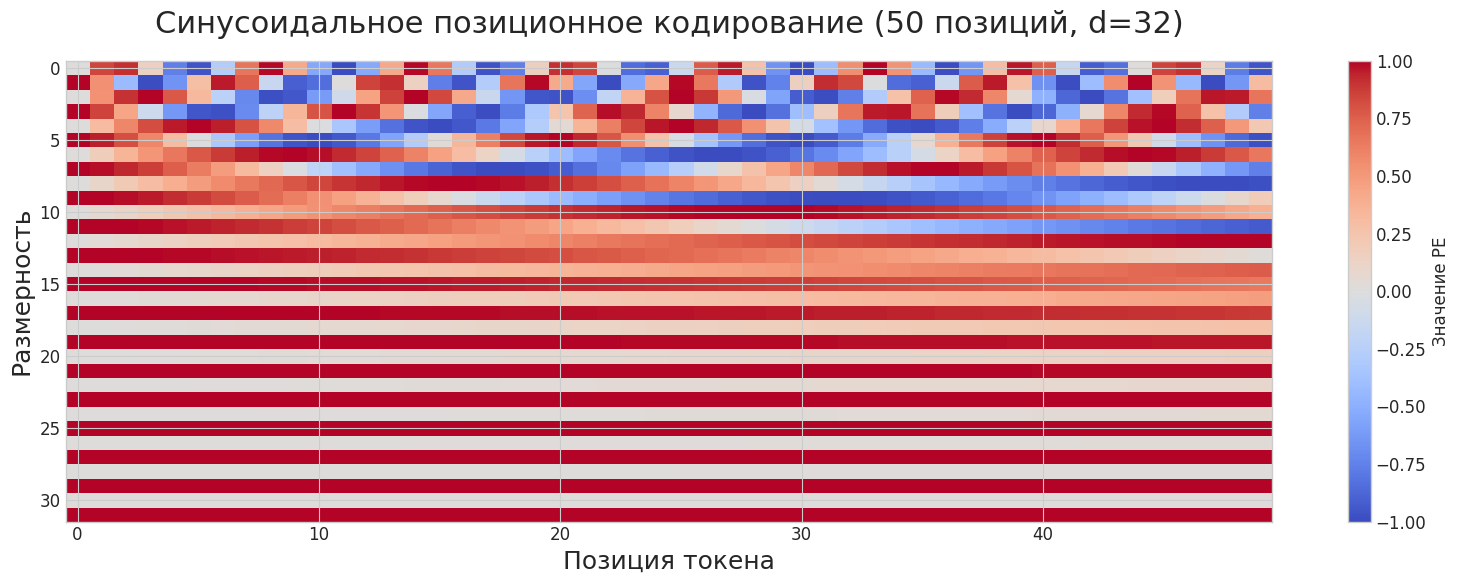

Максимальная разница без PE: 0.00000024
Без PE: attention инвариантен к перестановкам [OK]

Максимальная разница с PE: 1.95049143
С PE: attention эквивариантен к перестановкам [OK]

Без позиционного кодирования attention инвариантен к перестановкам: выход не меняется.
С позиционным кодированием attention чувствителен к порядку (эквивариантен):
 перестановка входов приводит к такой же перестановке выходов, но не сохраняет порядок.


In [5]:
# Задача 4. Позиционное кодирование

def sinusoidal_pe(max_len, d_model):
    """Синусоидальное позиционное кодирование.
    R - матрица позиционного кодирования, инициализируется нулями
    """
    if d_model % 2 != 0:
        raise ValueError("Размер эмбеддинга модели должен быть четным")
    R = torch.zeros(max_len, d_model)
    div = 1 / torch.pow(10000.0,  # через 1 / будет красивее
                        torch.arange(0, d_model, 2) / d_model)
    pos = torch.arange(0, max_len).unsqueeze(1)  # в тензор-столбец
    R[:, 0::2] = torch.sin(pos * div)
    R[:, 1::2] = torch.cos(pos * div)
    return R


# ============================ Визуализация ============================
max_len = 50
d_model = 32
pe = sinusoidal_pe(max_len, d_model)

plt.figure(figsize=(16, 6))
hmap = plt.imshow(pe.T,
                  cmap="coolwarm",
                  aspect="auto",
                  vmax=1,
                  vmin=-1)
plt.colorbar(hmap, label="Значение PE")
plt.xlabel("Позиция токена", size=18)
plt.ylabel("Размерность", size=18)
plt.title(f"Синусоидальное позиционное кодирование (50 позиций, d={d_model})",
          size=22, pad=20)
plt.tight_layout()
plt.show()

# ====== Демонстрация: без PE перестановка не влияет на attention ======
torch.manual_seed(SEED)
d_model = 16
seq_len = 4

# Случайные эмбеддинги (без позиции)
X = torch.randn(
    # здесь, на первой позиции, должна быть позиция бача, для себя. Пока путаюсь
    seq_len,
    d_model
)

# Прямой порядок
out_orig, _ = scaled_dot_product_attention(
    X.unsqueeze(0),
    X.unsqueeze(0),
    X.unsqueeze(0),
)

# Перемешиваем токены
perm = torch.randperm(seq_len)
X_perm = X[perm]
out_perm, _ = scaled_dot_product_attention(
    X_perm.unsqueeze(0),
    X_perm.unsqueeze(0),
    X_perm.unsqueeze(0)
)

# Возвращаем исходный порядок для сравнения
inv_perm = torch.argsort(perm)
out_perm_restored = out_perm[0, inv_perm, :]
diff_no_pe = torch.max(torch.abs(out_orig[0] - out_perm_restored))
print(f"Максимальная разница без PE: {diff_no_pe:.8f}")
print("Без PE: attention инвариантен к перестановкам " +
      ("[OK]" if diff_no_pe < 1e-6 else "[Ошибка]"))
print()

# ========================== Демонстрация с PE =========================
pe_emb = sinusoidal_pe(max_len, d_model)[:seq_len, :]
X_pe = X + pe_emb
X_perm_pe = X_perm + pe_emb
out_pe, _ = scaled_dot_product_attention(
    X_pe.unsqueeze(0),
    X_pe.unsqueeze(0),
    X_pe.unsqueeze(0)
)
out_perm_pe, _ = scaled_dot_product_attention(
    X_perm_pe.unsqueeze(0),
    X_perm_pe.unsqueeze(0),
    X_perm_pe.unsqueeze(0)
)
out_perm_pe_restored = out_perm_pe[0, inv_perm, :]
diff_with_pe = torch.max(torch.abs(out_pe[0] - out_perm_pe_restored))
print(f"Максимальная разница с PE: {diff_with_pe:.8f}")
print("С PE: attention эквивариантен к перестановкам " +
      ("[OK]" if diff_with_pe > 1e-6 else "[Ошибка]"))
print()
print("Без позиционного кодирования attention инвариантен к перестановкам: " +
      "выход не меняется.")
print("С позиционным кодированием attention чувствителен к порядку " +
      "(эквивариантен):\n перестановка входов приводит к такой же перестановке " +
      "выходов, но не сохраняет порядок.")

---

# СРЕДНИЕ ЗАДАЧИ (5—7)

Сборка компонентов Transformer, сравнение с RNN.

## Задача 5. Multi-head attention с нуля

### Постановка задачи

Реализуйте класс `MultiHeadAttention` с нуля (без `nn.MultiheadAttention`).

### Задача
1. `__init__(d_model, n_heads)`: создайте проекции $W_Q, W_K, W_V, W_O$.
2. `forward(x, mask=None)`: split по головам, attention в каждой голове, concat, проекция $W_O$.
3. Проверьте на $d_{model}=32$, $n_{heads}=4$, seq_len=6.
4. Подсчитайте число параметров.


In [6]:
# Задача 5. Multi-head attention с нуля

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, bias=False):
        super().__init__()
        if d_model % n_heads != 0:  # check размерности голов
            raise ValueError("`d_model` должен делиться на `n_heads`")
        self.d_model_ = d_model
        self.n_heads_ = n_heads
        self.head_dim_ = d_model // n_heads

        # Линейные проекции Q, K, V
        self._WQ = nn.Linear(d_model, d_model, bias)
        self._WK = nn.Linear(d_model, d_model, bias)
        self._WV = nn.Linear(d_model, d_model, bias)
        # Выходная проекция (пустая)
        self._WO = nn.Linear(d_model, d_model, bias)

    def forward(self, x, mask=None):
        """
        x: (batch, seq_len, d_model)
        mask: (batch, seq_len, seq_len) или None
        """
        batch, seq_len, _ = x.shape
        LayerQ = self._WQ(x)
        LayerK = self._WK(x)
        LayerV = self._WV(x)

        # Разделяю матрицы LayerQ, LayerK, LayerV на соответствующие головы
        # т.е. добавляю к каждой матрице головы
        QH = (LayerQ
              .view(batch, seq_len, self.n_heads_, self.head_dim_).transpose(1, 2))
        KH = (LayerK
              .view(batch, seq_len, self.n_heads_, self.head_dim_).transpose(1, 2))
        VH = (LayerV
              .view(batch, seq_len, self.n_heads_, self.head_dim_).transpose(1, 2))

        E = QH @ KH.transpose(-2, -1) / (self.head_dim_ ** (1/2))
        if mask is not None:
            if mask.dim() == 2:
                mask = mask.unsqueeze(0).unsqueeze(1)  # (1, 1, seq_len, seq_len)
            elif mask.dim() == 3:
                mask = mask.unsqueeze(1)  # (batch, 1, seq_len, seq_len)

            E = E.masked_fill(mask == 0, -1e9)
        
        W = torch.softmax(E, dim=-1)  # (batch, n_heads, seq_len, seq_len)
        output = W @ VH  # (batch, n_heads, seq_len, head_dim)

        # Сбор голов
        output = (output
                  .transpose(1, 2)
                  .contiguous()
                  .view(batch, seq_len, self.d_model_))
        
        # Проекция результата в пространство выхода 
        output = self._WO(output)
        return output, W


# ============================ Тестирование ============================
d_model, n_heads = 32, 4
mha = MultiHeadAttention(d_model, n_heads)

x = torch.randn(2, 6, d_model)
output, weights = mha(x)
output_d = output.shape[2]

print(f"Вход:     {x.shape}")
print(f"Выход:    {output.shape}")
print(f"Веса:     {weights.shape}  (batch, n_heads, seq_q, seq_k)")
print()

total_params = sum(p.numel() for p in mha.parameters())
print(f"Число параметров MHA: {total_params:,}")
print(f"  W_Q: {output_d}x{output_d} = {output_d*output_d}")
print(f"  W_K: {output_d}x{output_d} = {output_d*output_d}")
print(f"  W_V: {output_d}x{output_d} = {output_d*output_d}")
print(f"  W_O: {output_d}x{output_d} = {output_d*output_d}")
print(f"  Итого: 4 * {output_d}^2 = {4*output_d*output_d}")

# =================== Проверка суммы весов внимания ====================
assert torch.allclose(
    weights.sum(dim=-1),
    torch.ones_like(weights.sum(dim=-1)),
    atol=1e-6
)

# ============ Сравнение размерностей с базовой реализацией ============
# Torch MHA
torch.manual_seed(42)
torch_mha = nn.MultiheadAttention(
    d_model,
    n_heads,
    bias=False,
    batch_first=True,
)
x = torch.randn(2, 6, d_model)
t_output, t_weights = torch_mha(x, x, x)
assert t_output.shape == output.shape

"Здесь нашел косяк, хотя с ноутбуков преподавателя всё сошлось"
t_weights.shape == weights.shape

Вход:     torch.Size([2, 6, 32])
Выход:    torch.Size([2, 6, 32])
Веса:     torch.Size([2, 4, 6, 6])  (batch, n_heads, seq_q, seq_k)

Число параметров MHA: 4,096
  W_Q: 32x32 = 1024
  W_K: 32x32 = 1024
  W_V: 32x32 = 1024
  W_O: 32x32 = 1024
  Итого: 4 * 32^2 = 4096


False

> Косяк заключается в версии `PyTorch` - в моей версии вывод weights.shape немного отличается

---

## Задача 6. Сборка Transformer Encoder Layer

### Постановка задачи

Реализуйте один слой Transformer Encoder с нуля.

### Структура (post-norm)
```
x -> MHA -> Add(x) -> LayerNorm -> FFN -> Add -> LayerNorm -> output
```

### Задача
1. Используйте `MultiHeadAttention` из задачи 5.
2. FFN: $\text{Linear}(d_{model}, d_{ff}) \to \text{ReLU} \to \text{Linear}(d_{ff}, d_{model})$.
3. $d_{model}=64$, $n_{heads}=4$, $d_{ff}=256$.
4. Проверьте: output.shape == input.shape.
5. Подсчитайте число параметров.


In [7]:
# Задача 6. Transformer Encoder Layer

class TransformerEncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.0):
        super().__init__()
        if d_model % n_heads != 0:
            raise ValueError("`d_model` должен делиться на `n_heads`")
        self.d_model_ = d_model
        self.n_heads_ = n_heads
        self.d_ff_ = d_ff

        # ======================= Создание слоёв =======================
        self.A = MultiHeadAttention(d_model, n_heads)  # MHA слой
        self.norm1 = nn.LayerNorm(d_model)  # нормализация 1
        self.norm2 = nn.LayerNorm(d_model)  # нормализация 2

        # ================= Созданиее FeedForward сети =================
        self.ffn = nn.Sequential(  # FNN: Linear -> ReLU -> Linear
            nn.Linear(d_model, d_ff),  # -> 64x256
            nn.ReLU(),
            nn.Linear(d_ff, d_model)  # -> 256x64
        )

        # ======================== Регуляризация =======================
        if dropout < 0:
            raise ValueError("`dropout` должен быть >= 0")
        elif dropout > 0:  #  Регуляризация 
            self.dropout1 = nn.Dropout(dropout)
            self.dropout2 = nn.Dropout(dropout)
        else:
            #  Проходной слой регуляризации (сквозной, ничего не делаем)
            self.dropout1 = nn.Identity()
            self.dropout2 = nn.Identity()

    def forward(self, x, mask=None):
        # ======== Self-attention + residual + norm (post-norm) ========
        # x -> MHA -> Add(x) -> LayerNorm -> FFN -> Add -> LayerNorm -> output
        A_out, A_weights = self.A(x, mask)  # (batch, seq_len, d_model)
        A_out = self.dropout1(A_out)  # Регуляризация 1
        x = self.norm1(x + A_out)  # Соединение + линейное преобразование 1

        # ==================== FFN + residual + norm ===================
        ffn_out = self.ffn(x)  # То же, что и `self.A(x, mask)`
        ffn_out = self.dropout2(ffn_out)  # Регуляризация 2
        x = self.norm2(x + ffn_out)  # Соединение + линейное преобразование 2

        return x, A_weights


# ============================ Тестирование ============================
d_model = 64
n_heads = 4
d_ff = 256
enc_layer = TransformerEncoderLayer(d_model, n_heads, d_ff)

x = torch.randn(2, 10, d_model)
output, weights = enc_layer(x)

print(f"Вход:  {x.shape}")
print(f"Выход: {output.shape}")
assert output.shape == x.shape, "Форма должна сохраняться!"
print("[OK] Форма сохраняется.")
print()

# Подсчет параметров
numel_ENC_LAYER = [x.numel() for x in enc_layer.parameters()]
# numel_ENC_LAYER = [4096, 4096, 4096, 4096, 64, 64, 64, 64, 16384, 256, 16384, 64]
total = sum(numel_ENC_LAYER)

numel_MHA = [x.numel() for x in enc_layer.A.parameters()]
# numel_MHA = [4096, 4096, 4096, 4096]
mha_p = sum(numel_MHA)

numel_FFN = [x.numel() for x in enc_layer.ffn.parameters()]
# numel_FFN = [16384, 256, 16384, 64]
ffn_p = sum(numel_FFN)

numel_NORM = (
    [x.numel() for x in enc_layer.norm1.parameters()]
    + [x.numel() for x in enc_layer.norm2.parameters()]
)
# numel_NORM = [64, 64, 64, 64]
norm_p = sum(numel_NORM)

print(f"Параметры Transformer Encoder Layer:")
print(f"  MHA:       {mha_p:>6,}")
print(f"  FFN:       {ffn_p:>6,}")
print(f"  LayerNorm: {norm_p:>6}")
print(f"  ИТОГО:     {total:>6,}")

Вход:  torch.Size([2, 10, 64])
Выход: torch.Size([2, 10, 64])
[OK] Форма сохраняется.

Параметры Transformer Encoder Layer:
  MHA:       16,384
  FFN:       33,088
  LayerNorm:    256
  ИТОГО:     49,728


---

## Задача 7. RNN vs Transformer: дальние зависимости

### Постановка задачи

Сравните RNN и Transformer на синтетической задаче,
требующей «запоминания» начала длинной последовательности.

### Задача
Последовательность из 0 и 1 длиной 50. Задача: определить,
совпадают ли первый и последний элементы (бинарная классификация).

1. Реализуйте RNN-классификатор (GRU + Linear).
2. Реализуйте Transformer-классификатор (2 Encoder слоя + mean pooling + Linear).
3. Обучите оба на 2000 train / 500 test, 20 эпох.
4. Сравните test accuracy.


Train: torch.Size([2000, 50, 1]), Test: torch.Size([500, 50, 1])
Баланс классов (train): 0.49

------------- RNN (GRU) -------------
   RNN эпоха 5/20  test_acc=0.4720
   RNN эпоха 10/20  test_acc=0.4720
   RNN эпоха 15/20  test_acc=0.4720
   RNN эпоха 20/20  test_acc=0.4720

------------ Transformer ------------
   Transformer эпоха 5/20  test_acc=0.4720
   Transformer эпоха 10/20  test_acc=0.4700
   Transformer эпоха 15/20  test_acc=0.4720
   Transformer эпоха 20/20  test_acc=0.4720


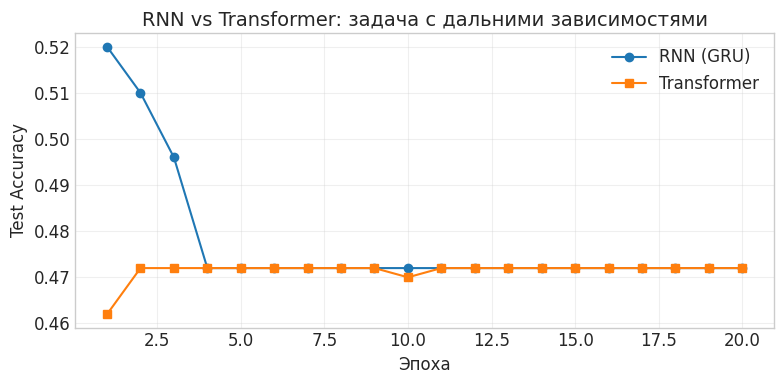



Итоговая accuracy:
  RNN:         0.4720
  Transformer: 0.4720


In [8]:
# Задача 7. RNN vs Transformer

torch.manual_seed(SEED)
np.random.seed(SEED)

SEQ_LEN = 50

# =================== Генерация последовательностей ====================
def generate_first_last_data(n, seq_len=SEQ_LEN):
    """Генерация: label = 1, если первый и последний элементы совпадают."""
    X = np.random.randint(0, 2, size=(n, seq_len)).astype(np.float32)  # float16 и int не могу, падает
    y = (X[:, 0] == X[:, -1]).astype(np.float32)
    # X: (num_seq, seq_len, bach)
    # y: (num_seq), плоский
    return torch.tensor(X).unsqueeze(-1), torch.tensor(y)


X_train, y_train = generate_first_last_data(n=2000)  # 2000 train
X_test, y_test = generate_first_last_data(n=500)  # 500 test
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Баланс классов (train): {y_train.mean():.2f}")

train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=64,
    shuffle=True
)
test_loader = DataLoader(
    TensorDataset(X_test, y_test),
    batch_size=64,
    shuffle=False
)


# ========================== RNN-классификатор =========================
class RNNClassifier(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=32, n_layers=1):
        super().__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, n_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        "x: (batch, seq_len, input_dim)"
        _, h_n = self.gru(x)  # h_n: (n_layers, batch, hidden_dim)
        x = h_n[-1]
        return self.fc(x).squeeze(-1)

# ===================== Transformer-классификатор ======================
class TransformerClassifier(nn.Module):
    def __init__(self, input_dim=1, d_model=32, n_heads=4, d_ff=64, n_layers=2):
        super().__init__()
        self.input_proj_ = nn.Linear(input_dim, d_model)
        self.enc_pos_ = sinusoidal_pe(SEQ_LEN, d_model)
        enc_layer = nn.TransformerEncoderLayer(
            d_model,
            n_heads,
            d_ff, batch_first=True  # иначе ошибка, бач будет последним значением
        )
        self.encoder = nn.TransformerEncoder(enc_layer, n_layers)
        self.fc = nn.Linear(d_model, 1)

    def forward(self, x):
        x = self.input_proj_(x)  # x: (batch, seq_len, d_model)
        x = x + self.enc_pos_[:x.size(1)].to(x.device)
        x = self.encoder(x)
        x = x.mean(dim=1)  # pooling mean
        return self.fc(x).squeeze(-1)

def train_classifier(model, name, epochs=20):
    bce_ll = nn.BCEWithLogitsLoss()
    lr = 1e-4  # вместо 1e-3 на 1e-4 сошлось на 4720

    adam = torch.optim.Adam(model.parameters(), lr=lr)
    model_accuracy = []
    for epoch in range(1, epochs + 1):
        model.train()
        for X, y in train_loader:
            adam.zero_grad()
            loss = bce_ll(model(X), y.float())
            loss.backward()
            adam.step()

        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for X, y in test_loader:
                pred = torch.sigmoid(model(X))
                correct += ((pred > 0.5) == y).sum().item()
                total += y.size(0)
        acc = correct / total
        model_accuracy.append(acc)
        if epoch % 5 == 0:
            print(f"   {name} эпоха {epoch}/{epochs}  test_acc={acc:.4f}")
    return model_accuracy


# ============================== Обучение ==============================
print()
print("-" * 13 + " RNN (GRU) " + "-" * 13)
rnn_accs = train_classifier(RNNClassifier(), "RNN", epochs=20)
print()
print("-" * 12 + " Transformer " + "-" * 12)
tr_accs = train_classifier(TransformerClassifier(), "Transformer", epochs=20)

# ============================ Визуализация ============================
plt.figure(figsize=(8, 4))
plt.plot(range(1, 21), rnn_accs, 'o-', label='RNN (GRU)')
plt.plot(range(1, 21), tr_accs, 's-', label='Transformer')
plt.xlabel('Эпоха'); plt.ylabel('Test Accuracy')
plt.title('RNN vs Transformer: задача с дальними зависимостями')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

print()
print(f"\nИтоговая accuracy:")
print(f"  RNN: {rnn_accs[-1]:>14.4f}")
print(f"  Transformer: {tr_accs[-1]:.4f}")

>**Наблюдения по задаче:**

Transformer фиксируется на `accuracy == 0.4720` практически сразу, если в `train_classifier` указать `lr = 1e-4 вместо 1e-3`. На что обратил внимание: `RNN приходит "сверху вниз", а Transformer "снизу вверх"`

---

# ЗАДАЧИ ВЫСОКОЙ СЛОЖНОСТИ (8—9)

Языковая модель и анализ attention.

## Задача 8. Мини decoder-only Transformer (char-level LM)

### Постановка задачи

Реализуйте маленькую авторегрессивную языковую модель на уровне символов.

### Задача
1. Определите корпус текста (несколько предложений на русском).
2. Постройте словарь символов.
3. Реализуйте decoder-only Transformer: embedding + PE + 2 decoder слоя + LM head.
4. Обучите модель с causal mask.
5. Сгенерируйте текст авторегрессивно.


Длина корпуса:  725 символов
Размер словаря: 51
Обучающих примеров: 693

------------- Обучение `CharTransformerLM` -------------
Эпоха 10/50  loss=0.8901
Эпоха 20/50  loss=0.5835
Эпоха 30/50  loss=0.4695
Эпоха 40/50  loss=0.4102
Эпоха 50/50  loss=0.3638


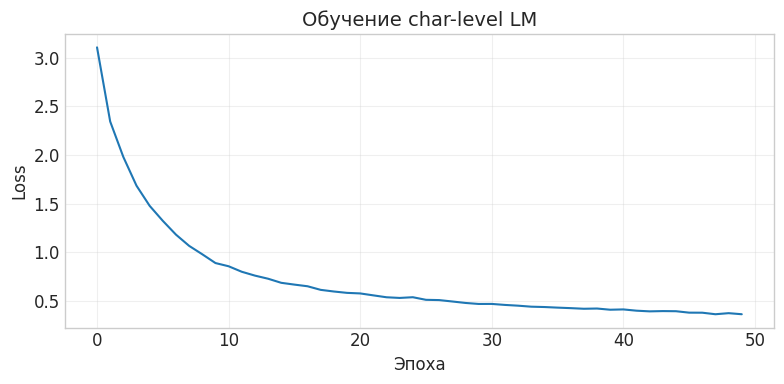

In [9]:
# Задача 8. Мини decoder-only Transformer

torch.manual_seed(SEED)

# =============================== Корпус ===============================
corpus = (
    "Нейронные сети представляют собой мощный инструмент машинного обучения. "
    "Глубокое обучение позволяет автоматически извлекать признаки из данных. "
    "Архитектура Transformer произвела революцию в обработке естественного языка. "
    "Механизм внимания позволяет модели фокусироваться на релевантных частях входа. "
    "Языковые модели предсказывают следующий токен на основе контекста. "
    "Обучение нейронных сетей требует больших объемов данных и вычислительных ресурсов. "
    "Регуляризация помогает избежать переобучения модели на тренировочных данных. "
    "Функция потерь определяет качество предсказаний модели. "
    "Градиентный спуск является основным методом оптимизации параметров. "
    "Обратное распространение ошибки позволяет эффективно вычислять градиенты. "
)


# ====================== Токенизация (char-level) ======================
chars_dict = sorted(list(set(corpus)))
vocab_size = len(chars_dict)
char_idxs = {ch: idx for idx, ch in enumerate(chars_dict)}
print(f"Длина корпуса:  {len(corpus)} символов")
print(f"Размер словаря: {vocab_size}")


# ========================= Подготовка данных ==========================
CONTEXT_LEN = 32

def make_sequences(data, ctx_len):
    X, Y = [], []
    # X, Y должны иметь одинаковую форму: (num_examples, ctx_len)
    for idx in range(len(data) - ctx_len):
        X.append([char_idxs[ch] for ch in data[idx: idx + ctx_len]])
        Y.append([char_idxs[ch] for ch in data[idx+1: idx+1+ctx_len]])
    return (torch.tensor(X, dtype=torch.long),  # с float32 не сработало
            torch.tensor(Y, dtype=torch.long))

X_lm, Y_lm = make_sequences(corpus, CONTEXT_LEN)
print(f"Обучающих примеров: {len(X_lm)}")

lm_loader = DataLoader(TensorDataset(X_lm, Y_lm), batch_size=16, shuffle=True)


# ====================== Decoder-only Transformer ======================
class CharTransformerLM(nn.Module):
    def __init__(self,
                 vocab_size,
                 d_model=64,
                 n_heads=4,
                 d_ff=128,
                 n_layers=2,
                 max_len=128):
        super().__init__()
        self.d_model_ = d_model
        self.enc_pos_ = sinusoidal_pe(max_len, d_model)
        self.embedding_ = nn.Embedding(vocab_size, d_model)
        self.lm_head_ = nn.Linear(d_model, vocab_size)
        decoder_layer = nn.TransformerDecoderLayer(d_model,
                                                   n_heads,
                                                   d_ff,
                                                   batch_first=True)
        self.decoder_ = nn.TransformerDecoder(decoder_layer, n_layers)

    def forward(self, x):
        # x: (batch, seq_len)
        seq_len = x.size(1)
        # causal mask (верхний треугольник, маскирую т.слово+1)
        mask = torch.triu(torch.ones(seq_len, seq_len) * -np.inf,
                          diagonal=1).to(x.device)
        x = self.embedding_(x) * (self.d_model_ ** (1/2))
        x = x + self.enc_pos_[:seq_len].to(x.device)
        x = self.decoder_(x, torch.zeros_like(x), tgt_mask=mask)
        logits = self.lm_head_(x)  # выход: (batch, seq_len, vocab_size)
        return logits

model_lm = CharTransformerLM(vocab_size).to(device)
optimizer = optim.Adam(model_lm.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()


# ============================== Обучение ==============================
print()
print("-" * 13 + " Обучение `CharTransformerLM` " + "-" * 13)
lm_losses = []
epochs = 50
for epoch in range(1, epochs + 1):
    model_lm.train()
    total_loss = 0
    for X_batch, Y_batch in lm_loader:
        # X_batch: (batch, ctx_len), Y_batch: (batch,)
        X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
        optimizer.zero_grad()
        logits = model_lm(X_batch)  # logits: (batch, ctx_len, vocab_size)
        # logits_last = logits[:, -1, :]  # logits_last: (batch, vocab_size) | # берём логиты последнего токена
        loss = criterion(logits.reshape(-1, vocab_size), Y_batch.reshape(-1))
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(lm_loader)
    lm_losses.append(avg_loss)
    if epoch % 10 == 0:
        print(f"Эпоха {epoch}/{epochs}  loss={avg_loss:.4f}")


plt.figure(figsize=(8, 4))
plt.plot(lm_losses)
plt.xlabel('Эпоха'); plt.ylabel('Loss')
plt.title('Обучение char-level LM'); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


# ========================== Генерация текста ==========================
idxs_char = {idx: ch for idx, ch in enumerate(chars_dict)}

def generate_text(model, seed_text, length=150, temperature=1.0):
    model.eval()
    device = next(model.parameters()).device
    generated = seed_text
    for _ in range(length):
        input_ids = [char_idxs.get(ch, char_idxs[' ']) for ch in generated[-CONTEXT_LEN:]]
        input_tensor = torch.tensor([input_ids], dtype=torch.long).to(device)  # (1, seq_len)
        with torch.no_grad():
            logits = model(input_tensor)  # (1, seq_len, vocab_size)
            logits_last = logits[0, -1, :] / temperature  # (vocab_size,)
            probs = torch.softmax(logits_last, dim=-1)
            next_idx = torch.multinomial(probs, 1).item()
        next_char = idxs_char[next_idx]
        generated += next_char

    return generated

In [10]:
# ======================== Предсказание текста =========================
print("\n--- Сгенерированный текст (temperature=0.8) ---")
seed = "Нейронные сети "
predict_text = generate_text(model_lm, seed, length=150, temperature=0.8)
print("  output↴\n   \"" + predict_text + "\"", end="\n" * 2)

seed = "Функция потерь "
predict_text = generate_text(model_lm, seed, length=150, temperature=0.8)
print("  output↴\n   \"" + predict_text + "\"", end="\n" * 2)

seed = "нейронных сетей требует "
predict_text = generate_text(model_lm, seed, length=150, temperature=0.8)
print("  output↴\n   \"" + predict_text + "\"", end="\n" * 2)


--- Сгенерированный текст (temperature=0.8) ---
  output↴
   "Нейронные сети представляют собой мощный инструменнт машинного о о обучения. Глубокое обучение позволяет автоматически извлекать признакиз из дакизных. Архитектура T"

  output↴
   "Функция потерь определяет качестство предсказаний модели. Градиентный спуск являетсяется ося основным метогобризация. поляет ат Механизмеха внияетимания позволяет мо"

  output↴
   "нейронных сетей требует больших объемов данных и вычислительных ресурсов. Регуляризация помогает избежать переобучения пена модели ни тровочных даных. Функцияе потерь определ"



---

## Задача 9. Визуализация attention и стратегии декодирования

### Постановка задачи

Используя модель из задачи 8, визуализируйте матрицы внимания
и сравните разные стратегии генерации текста.

### Задача
1. Извлеките и визуализируйте attention weights для 2—3 голов.
2. Реализуйте три стратегии декодирования: greedy, temperature, top-k.
3. Сгенерируйте текст каждой стратегией и сравните результаты.


In [ ]:
# Задача 9. Визуализация attention и стратегии декодирования

# --- Визуализация attention ---
# model_lm.eval()
sample_text = "Нейронные сети представляют"
# sample_ids =

# with torch.no_grad():
#     _, attn_all = model_lm(sample_ids)

# attn_all[layer]: (B, n_heads, seq, seq)
n_show_heads = 3
fig, axes = plt.subplots(1, n_show_heads, figsize=(5 * n_show_heads, 5))
labels = list(sample_text)

# for h_idx in range(n_show_heads):
# ваш код здесь

plt.suptitle('Матрицы внимания (causal, первый слой)')
plt.tight_layout(); plt.show()

# --- Стратегии декодирования ---
def generate_greedy(model, seed_text, length=100):
    """Жадное декодирование: всегда выбирается argmax."""
    assert #ваш код здесь

def generate_temperature(model, seed_text, length=100, temperature=1.0):
    """Сэмплирование с температурой."""
    assert #ваш код здесь

def generate_top_k(model, seed_text, length=100, k=5, temperature=1.0):
    """Top-k сэмплирование."""
    assert #ваш код здесь

seed = "Глубокое обучение "

"""
print("=" * 60)
print("GREEDY:")
print(generate_greedy(model_lm, seed, 150))
print()

print("=" * 60)
print("TEMPERATURE = 0.5 (более детерминированный):")
print(generate_temperature(model_lm, seed, 150, temperature=0.5))
print()

print("=" * 60)
print("TEMPERATURE = 1.5 (более случайный):")
print(generate_temperature(model_lm, seed, 150, temperature=1.5))
print()

print("=" * 60)
print("TOP-K (k=5):")
print(generate_top_k(model_lm, seed, 150, k=5))
print()

print("=" * 60)
print("TOP-K (k=3):")
print(generate_top_k(model_lm, seed, 150, k=3))
print()

print("Анализ:")"""

# анализ здесь